# EI Tuning — Wilson-Cowan Whole-Brain Model

각 셀은 독립적인 파트를 담당한다. **파라미터 수정은 Cell 2에서만 한다.**

In [1]:
# JAX 메모리 설정: import 전에 반드시 실행해야 한다
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

import jax
jax.config.update("jax_enable_x64", False)

print(f"backend : {jax.default_backend()}")
print(f"devices : {jax.devices()}")
print(f"jax_enable_x64 : {jax.config.jax_enable_x64}")

from config              import Config
from data_loader         import load_data
from model               import build_network
from part1_fic           import run_fic
from part2_eib           import run_eib
from part3_gradient      import run_gradient_optimization, run_lowrank_optimization
from part4_dbs           import run_dbs_stimulation
from pipeline_contracts  import ParamSet, StateBundle, capture_internal_state, capture_network_delay_history


backend : gpu
devices : [CudaDevice(id=0)]
jax_enable_x64 : False


## Cell 2 — Config

**파라미터 수정은 이 셀에서만 한다.**

In [2]:
cfg = Config(
    # ── 데이터 경로 ──────────────────────────────────────────
    region_txt                          = "Atlas_43.txt",
    sc_csv                              = "weight_nor.csv",
    length_csv                          = "tract_length_nor.csv",
    fc_csv                              = "FC_nor.csv",

    # ── 시뮬레이션 공통 ──────────────────────────────────────
    integration_dt_ms                   = 1.0,
    warmup_duration_ms                  = 300_000,
    bold_repetition_time_ms             = 1000.0,
    tract_conduction_speed              = 3.0,
    additive_noise_sigma                = 0.02,

    # ── Part 1 — FIC (구버전 notebook 로직) ─────────────────
    fic_target_firing_rate_hz           = 2.0,
    fic_learning_rate                   = 1e-3,
    fic_max_iterations                  = 2000,
    fic_early_stop_patience             = 500,
    fic_early_stop_tolerance_hz         = 0.10,
    fic_step_duration_ms                = 1_000,
    fic_step_skip_tr                    = 0,

    # ── Part 2 — EIB (구버전 notebook 로직) ─────────────────
    eib_max_iterations                  = 8000,
    eib_internal_fic_learning_rate      = 0.05,
    eib_max_weight_learning_rate        = 0.002,
    eib_bold_window_samples             = 150,
    eib_snapshot_save_interval          = 50,
    connectivity_weight_max             = 1.5,
    eib_posthoc_top_k                   = 10,
    eib_posthoc_duration_ms             = 300_000,
    eib_posthoc_skip_tr                 = 20,

    # ── Part 3 — Full Gradient (구버전 notebook 로직) ───────
    optimizer_learning_rate             = 0.0002,
    optimizer_max_steps                 = 2000,
    optimizer_chunk_steps               = 10,
    optimizer_bold_window_tr            = 240,
    optimizer_bold_skip_tr              = 30,

    # ── Part 3B — Low-rank (사용자 지정: Full Gradient 결과 기반) ──
    lowrank_rank                        = 6,
    lowrank_max_steps                   = 200,
    lowrank_learning_rate               = 0.0002,
    lowrank_bold_window_tr              = 240,
    lowrank_bold_skip_tr                = 30,
    lowrank_delta_scale                 = 0.15,
    lowrank_factor_init                 = 0.01,
    lowrank_activity_weight             = 0.01,
    lowrank_factor_penalty              = 1e-4,
    lowrank_seed                        = 17,

    # ── Phase 1 final baseline settle ────────────────────────
    baseline_settle_duration_ms         = 0,

    # ── EIB score 계산용 ──────────────────────────────────────
    pd_fit_region_count                 = 14,
    full_brain_fc_loss_weight           = 1.00,
    pd_fit_block_loss_weight            = 0.00,
    correlation_loss_weight             = 0.80,   # EIB scoring (keep)
    rmse_loss_weight                    = 0.20,   # EIB scoring (keep)

    # ── Patch 9: Gradient / LowRank 3-term loss weights ──────
    optimizer_global_corr_weight        = 0.40,   # alpha: global FC corr
    optimizer_nodewise_corr_weight      = 0.40,   # beta:  node-wise FC corr
    optimizer_rmse_weight               = 0.20,   # gamma: global FC RMSE
    lowrank_global_corr_weight          = 0.40,
    lowrank_nodewise_corr_weight        = 0.40,
    lowrank_rmse_weight                 = 0.20,

    # ── Part 4 — DBS ─────────────────────────────────────────
    dbs_pulse_amplitude                 = 10.0,
    dbs_stimulation_frequency_hz        = 130.0,
    dbs_phase_duration_steps            = 1,
    dbs_pre_stimulation_duration_ms     = 60_000.0,
    dbs_stimulation_duration_ms         = 60_000.0,
)
cfg.print_summary()

  Config
  region_txt                                   = Atlas_43.txt
  sc_csv                                       = weight_nor.csv
  length_csv                                   = tract_length_nor.csv
  fc_csv                                       = FC_nor.csv
  cache_root_dir                               = ./cache
  param_save_dir                               = ./optimized_params
  cache_version                                = v_eituning_oldlogic_match_p3
  integration_dt_ms                            = 1.0
  warmup_duration_ms                           = 300000
  bold_repetition_time_ms                      = 1000.0
  tract_conduction_speed                       = 3.0
  additive_noise_sigma                         = 0.02
  bundle_rng_seed                              = 42
  fc_plot_vmin                                 = -1.0
  fc_plot_vmax                                 = 1.0
  fic_target_firing_rate_hz                    = 2.0
  fic_learning_rate                            =

## Cell 3 — Data Loading

SC / tract_length / FC 로드 및 전처리. weights/delays/fc_target 행렬을 시각화한다.

Cache stored here: /scratch/home/wog3597/optim/cache/./cache/v_eituning_oldlogic_match_p3_N42_sc9d7fdc456e_fc7498c633b6


W0520 09:59:58.955655 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
E0520 09:59:58.991915 3123699 ptx_compiler_helpers.cc:132] *** WARNING *** Invoking ptxas with version 12.5.40, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
W0520 09:59:59.037778 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.125084 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.210740 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.259259 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.299033 3123699 sol_gpu_cost_model.cc:102] No SoL con

[DATA] n_nodes=42  SC nonzero=788
[DATA] weights:   min=0.0000e+00  max=1.0000e+00
[DATA] fc_target: min=-7.1268e-01  max=8.1145e-01
[DATA] delays:    min=0.00ms  max=3.38ms  (speed=3.0 mm/ms)
[DATA] SC mask:   788 / 1764  (44.7%)
[DATA] cache_tag = v_eituning_oldlogic_match_p3_N42_sc9d7fdc456e_fc7498c633b6
[DATA] Graph type: DenseDelayGraph


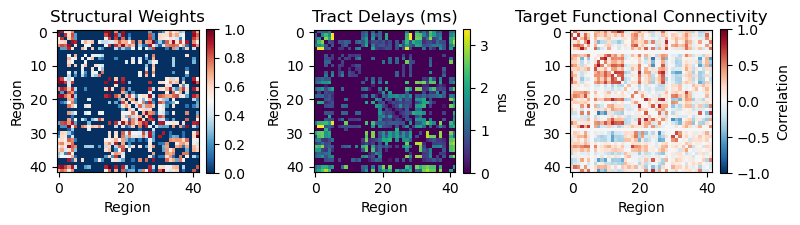

In [3]:
data = load_data(cfg)


## Cell 4 — Build Network & Warmup

In [4]:
network, initial_state, bold_monitor, warmup_result = build_network(cfg, data)

initial_params = ParamSet.default(data["n_nodes"]).sanitize(
    data["sc_mask"], cfg.connectivity_weight_max
)

bundle_init = StateBundle.from_warmup(
    warmup_result          = warmup_result,
    bold_monitor_template  = bold_monitor,
    initial_params         = initial_params,
    internal_state         = capture_internal_state(initial_state),
    delay_history          = capture_network_delay_history(network),
    stage                  = "warmup",
)

print(bundle_init)


W0520 09:59:59.828108 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.849913 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.888753 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.926605 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.963994 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 09:59:59.988386 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:00.023983 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:00.043415 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[MODEL] Running warmup simulation...


W0520 10:00:00.899384 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:00.919634 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:00.959056 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:01.159087 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:05.410683 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:05.454461 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:05.490972 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:05.511204 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[MODEL] Warmup done — E mean=0.9685  I mean=1.0000
[MODEL] Graph type: DenseDelayGraph


W0520 10:00:05.855233 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:05.901884 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:05.938827 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:05.980002 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:06.018010 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:06.038690 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:06.076329 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:06.097476 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

StateBundle(stage='warmup', c_ei_frozen=False, init_dyn_shape=(2, 42))


W0520 10:00:06.737778 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


## Pipeline timing diagnostics (read-only, Patch 3)

각 단계의 예상 소요 시간만 표시한다. 시뮬레이션을 실행하지 않으며 캐시를 건드리지 않는다.
JAX backend / device 확인, dispatch latency, 단계별 step×per-step 추정치 합산.

In [5]:
# === Pipeline timing diagnostics (Patch 3) ===
from timing_utils import estimate_stage, print_estimates, print_gpu_summary
import time as _t, jax, jax.numpy as _jnp

print_gpu_summary()

# JAX per-dispatch latency micro-benchmark
_n = data['n_nodes']
_x = _jnp.ones((_n, 2), dtype=_jnp.float32)
_f = jax.jit(lambda x: x * 1.0001 + 0.0001)
_f(_x).block_until_ready()  # warmup
_t0 = _t.perf_counter()
for _ in range(200):
    _x = _f(_x)
_x.block_until_ready()
_jax_latency = (_t.perf_counter() - _t0) / 200
print(f'\nJAX per-dispatch latency ≈ {_jax_latency*1000:.3f} ms (N={_n})')

_tr_ms = cfg.bold_repetition_time_ms
_cost = 0.0008  # GPU 기준 fallback (sim 1ms당 약 0.8ms wall)

# DBS baseline+stim per target: config의 dbs_pre_stimulation_duration_ms + dbs_stimulation_duration_ms
_dbs_pre = getattr(cfg, 'dbs_baseline_duration_ms', None)
if _dbs_pre is None:
    _dbs_pre = getattr(cfg, 'dbs_pre_stimulation_duration_ms', 60_000.0)
_dbs_total_per_target = float(_dbs_pre) + float(cfg.dbs_stimulation_duration_ms)

_estimates = [
    estimate_stage('FIC',
        n_steps=int(cfg.fic_max_iterations),
        fallback_step_sec=cfg.fic_step_duration_ms * _cost),
    estimate_stage('EIB-search',
        n_steps=int(cfg.eib_max_iterations),
        fallback_step_sec=_tr_ms * _cost),
    estimate_stage('EIB-posthoc',
        n_steps=int(cfg.eib_posthoc_top_k),
        fallback_step_sec=cfg.eib_posthoc_duration_ms * _cost),
    estimate_stage('Gradient',
        n_steps=int(cfg.optimizer_max_steps),
        fallback_step_sec=cfg.optimizer_bold_window_tr * _tr_ms * _cost),
    estimate_stage('LowRank',
        n_steps=int(cfg.lowrank_max_steps),
        fallback_step_sec=cfg.lowrank_bold_window_tr * _tr_ms * _cost),
    estimate_stage('DBS (per target)',
        n_steps=len(cfg.dbs_target_regions),
        fallback_step_sec=_dbs_total_per_target * _cost),
]
print_estimates(_estimates)

print('\n[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.')
print('[hint] cfg.optimizer_chunk_steps=5~10 시 Gradient ~10% 단축 (수렴 dynamics 변경 감수).')
print('[hint] 위 예측은 ±50% 오차. 실측은 각 run_* 의 [STAGE] 라인 참조.')

                        JAX backend / device summary                        
             backend: gpu
        device_count: 1
             devices: ['cuda:0']
      default_device: cuda:0
         x64_enabled: False

JAX per-dispatch latency ≈ 0.087 ms (N=42)
            Pipeline timing estimates (analytical + JAX latency)            
[             FIC] steps=  2000  per-step=  800.00ms  total≈26.7min
[      EIB-search] steps=  8000  per-step=  800.00ms  total≈1.78h
[     EIB-posthoc] steps=    10  per-step=240000.00ms  total≈40.0min
[        Gradient] steps=  2000  per-step=192000.00ms  total≈106.67h
[         LowRank] steps=   200  per-step=192000.00ms  total≈10.67h
[DBS (per target)] steps=     4  per-step=96000.00ms  total≈6.4min
----------------------------------------------------------------------------
                          TOTAL (excl. caching, compile)  ≈ 120.33h

[hint] Patch 3: cfg.posthoc_parallel=True 시 EIB-posthoc ~20-30% 단축.
[hint] cfg.optimizer_chunk_steps=5~10 시 G

W0520 10:00:06.772988 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:06.813297 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


## Cell 5 — Part 1: FIC

구버전 notebook 로직: **1초 step × 2000** 반복, `c_ei`는 아직 동결하지 않는다.

W0520 10:00:06.929811 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


Running computations for fic_v_eituning_oldlogic_match_p3_N42_sc9d7fdc456e_fc7498c633b6_rE2_eta0p001_steps2000_dur1000_skip0_fp85aaf2ae978f


W0520 10:00:07.104197 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:07.177351 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:07.215115 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:07.235352 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:07.255480 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:07.293267 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:07.482602 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:07.757804 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[FIC] target=2.0 Hz  eta=0.001  max_steps=2000
  step=1s  skip=0 TR  use=1 TR


W0520 10:00:08.216763 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:08.258793 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:08.296723 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:08.335402 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:08.373348 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:08.394358 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:08.432290 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:00:08.453997 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

...

  step 2000/2000  mean_E=0.1398  rE=2.795 Hz  err=0.795  (965.9s)


W0520 10:16:13.863716 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.176169 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.228009 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.263879 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.315154 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.367655 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


[FIC] Done — final mean_E=0.1398  final rE_hz=2.795 Hz  err=0.795 Hz


W0520 10:16:14.422357 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.454676 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.486048 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.527972 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.562784 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.616478 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.661775 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:14.694440 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

[FIC] c_ei updated.  mean c_ei = 19.4478  final rE_hz = 2.795 Hz


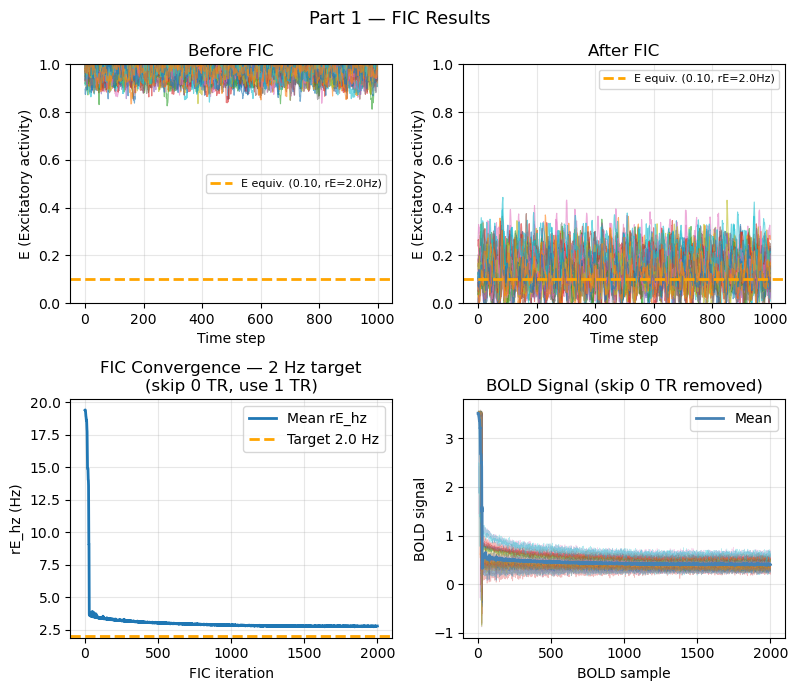

[FIC] FC comparison  Pre-opt corr=-0.0194, Pre-opt rmse=0.2772  Post-FIC corr=-0.0461, Post-FIC rmse=0.3090


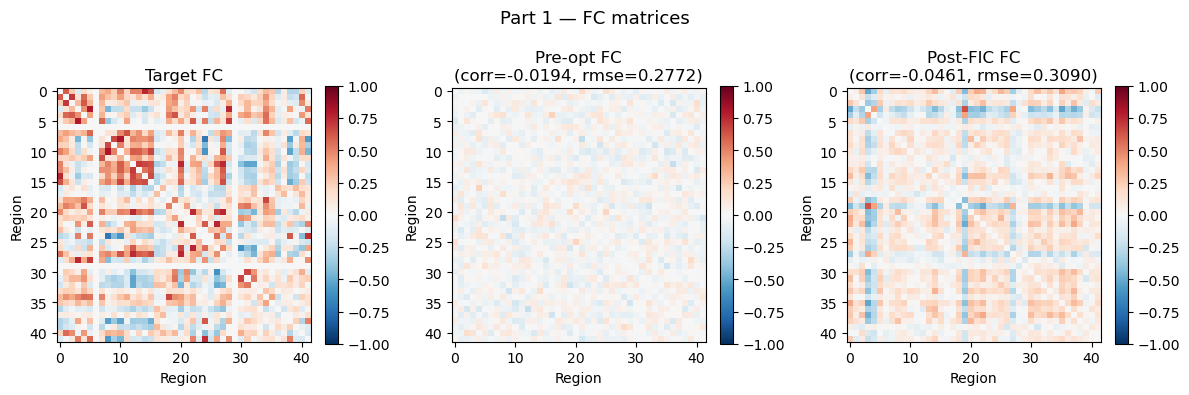

[FIC] c_ei_frozen=False  mean c_ei=19.4478
StateBundle(stage='fic', c_ei_frozen=False, init_dyn_shape=(2, 42))


In [6]:
# Part 1: FIC — 구버전 notebook 로직 (c_ei는 이후 단계에서도 계속 업데이트)
bundle_fic = run_fic(
    network   = network,
    bundle_in = bundle_init,
    cfg       = cfg,
    data      = data,
)
assert not bundle_fic.params.c_ei_frozen, "Old-logic FIC should keep c_ei unfrozen"
print(f"[FIC] c_ei_frozen={bundle_fic.params.c_ei_frozen}  mean c_ei={bundle_fic.params.c_ei.mean():.4f}")
print(bundle_fic)


## Cell 6 — Part 2: EIB Tuning

구버전 notebook 로직: **150 TR window / 8000 step / EIB 중에도 c_ei 업데이트**.

In [ ]:
# Part 2: EIB — 구버전 notebook 로직 (c_ei + wLRE/wFFI 동시 튜닝)
bundle_eib = run_eib(
    network   = network,
    bundle_in = bundle_fic,
    cfg       = cfg,
    data      = data,
)
assert not bundle_eib.params.c_ei_frozen, "Old-logic EIB should keep c_ei unfrozen"
print(f"[EIB] stage={bundle_eib.stage}  c_ei_frozen={bundle_eib.params.c_ei_frozen}")
print(bundle_eib)


Running computations for eib_v_eituning_oldlogic_match_p3_N42_sc9d7fdc456e_fc7498c633b6_win150_etaF0p05_etaE0p002_steps8000_topk10_frozen0_fpf8eafb24617b


W0520 10:16:30.993479 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:31.035741 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:31.245686 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.


[EIB] 1단계 탐색: 8000스텝 × 1 TR  window=150 TR  c_ei_frozen=False
      Step   Win-corr   Win-RMSE  Best-win-corr    Elapsed        ETA
----------------------------------------------------------------------


W0520 10:16:31.709372 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:32.022226 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:32.064000 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:32.122690 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:32.176549 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:32.214936 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:32.266638 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:16:32.311603 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

      50/8000       -0.0636      0.3171         -0.0528         30s  1h 21m 13s


...

W0520 10:34:18.936087 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:19.471178 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:19.976147 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:20.505596 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:21.042707 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:21.578404 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:22.087825 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:22.625699 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

    2050/8000       -0.0511      0.3029         -0.0154     18m 13s     52m 55s


W0520 10:34:45.239325 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:45.754512 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:46.277819 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:46.818489 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:47.361361 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:47.885648 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:48.428472 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:34:48.962828 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

    2100/8000       -0.0238      0.3015         -0.0154     18m 40s     52m 29s


W0520 10:35:12.085232 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:35:12.609002 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:35:13.147669 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:35:13.684282 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:35:14.229875 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:35:14.742161 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:35:15.282897 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL. Using default config.
W0520 10:35:15.830753 3123699 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 NVL

## Cell 7 — Part 3: Full-matrix Gradient Optimization

구버전 notebook 로직: **96 TR / skip 8 / c_ei·wLRE·wFFI 모두 dense 최적화**.

In [ ]:
# Part 3: Full-matrix Gradient Optimization
bundle_grad = run_gradient_optimization(
    network   = network,
    bundle_in = bundle_eib,
    cfg       = cfg,
    data      = data,
)
print(f"[Part3] stage={bundle_grad.stage}  c_ei_frozen={bundle_grad.params.c_ei_frozen}")
print(bundle_grad)


## Part 3B: Low-rank Gradient Optimization

사용자 지정 로직: **Low-rank는 Part 3 Full Gradient 결과를 시작점으로 사용**.

In [ ]:
# Part 3B: Low-rank Gradient Optimization (Full Gradient 결과 기반)
bundle_lowrank = run_lowrank_optimization(
    network   = network,
    bundle_in = bundle_grad,
    cfg       = cfg,
    data      = data,
)
print(f"[Part3B] stage={bundle_lowrank.stage}  c_ei_frozen={bundle_lowrank.params.c_ei_frozen}")
print(bundle_lowrank)


## Cell 8 — Part 4: DBS Stimulation

Biphasic pulse train 자극 + pre vs during PSD 비교

In [ ]:
# grad vs lowrank 중 corr이 더 높은 bundle을 DBS input으로 선택
from part3_gradient import compute_simulated_fc
from tvboptim.observations.observation import fc_corr
import jax.numpy as _jnp, numpy as _np

_fc_target = _jnp.asarray(data['fc_target'])
_sim_ms  = 180_000
_skip_tr = 30

print('\n' + '='*52)
print('  DBS input bundle 선택 (grad vs lowrank)')
print('='*52)

_fc_grad = compute_simulated_fc(network, bundle_grad, cfg, _sim_ms, _skip_tr)
_corr_grad = float(fc_corr(_jnp.asarray(_fc_grad), _fc_target))
print(f'  grad    corr={_corr_grad:.4f}')

_fc_lr = compute_simulated_fc(network, bundle_lowrank, cfg, _sim_ms, _skip_tr)
_corr_lr = float(fc_corr(_jnp.asarray(_fc_lr), _fc_target))
print(f'  lowrank corr={_corr_lr:.4f}')

print('-'*52)
if _corr_lr >= _corr_grad:
    bundle_for_dbs = bundle_lowrank
    print(f'  → DBS input: lowrank  (corr={_corr_lr:.4f})')
else:
    bundle_for_dbs = bundle_grad
    print(f'  → DBS input: grad  (corr={_corr_grad:.4f})')
print('='*52 + '\n')

run_dbs_stimulation(
    network   = network,
    bundle_in = bundle_for_dbs,
    cfg       = cfg,
    data      = data,
)

In [ ]:
from pathlib import Path
from datetime import datetime
from IPython.display import display, FileLink
import matplotlib.pyplot as plt
import zipfile
import shutil
import re

STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_ROOT = Path(f"all_figures_export_{STAMP}")
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# ---------------------------
# figure 저장용 helper
# ---------------------------
def _slugify(text: str) -> str:
    # 파일명으로 사용할 수 있게 텍스트 정제
    text = re.sub(r"\s+", "_", text.strip())
    text = re.sub(r"[^0-9A-Za-z가-힣_\-]+", "", text)
    return text[:120] if text else "figure"

def _infer_part_from_figure(fig) -> str:
    # Figure의 제목 정보를 바탕으로 적절한 파트 폴더 판별
    titles = []

    try:
        if getattr(fig, "_suptitle", None) is not None:
            supt = fig._suptitle.get_text()
            if supt:
                titles.append(supt)
    except Exception:
        pass

    for ax in fig.axes[:10]:
        try:
            t = ax.get_title()
            if t:
                titles.append(t)
        except Exception:
            pass

    joined = " | ".join(titles).lower()

    if "part 1" in joined or "fic" in joined:
        return "part1_fic"
    if "part 2" in joined or "eib" in joined:
        return "part2_eib"
    if "part 3b" in joined or "low-rank" in joined or "lowrank" in joined:
        return "part3b_lowrank"
    if "part 3" in joined or "gradient" in joined or "optim" in joined:
        return "part3_gradient"
    if "dbs" in joined or "lfp" in joined or "stimulus" in joined or "psd" in joined:
        return "part4_dbs"
    return "misc"

def _get_figure_title(fig, idx: int) -> str:
    # Figure의 제목을 추출하여 파일명으로 활용
    try:
        if getattr(fig, "_suptitle", None) is not None:
            supt = fig._suptitle.get_text()
            if supt:
                return supt
    except Exception:
        pass

    for ax in fig.axes:
        try:
            t = ax.get_title()
            if t:
                return t
        except Exception:
            pass

    return f"figure_{idx:03d}"

# ---------------------------
# plt.show() patch
# ---------------------------
# 기존 show 함수를 보존하고, 실행 시 저장을 먼저 하도록 패치함
if not hasattr(plt, "_oai_original_show"):
    plt._oai_original_show = plt.show

_plot_counter = {"n": 0}

def _save_all_open_figures():
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        _plot_counter["n"] += 1

        part_dir = SAVE_ROOT / _infer_part_from_figure(fig)
        part_dir.mkdir(parents=True, exist_ok=True)

        stem = _slugify(_get_figure_title(fig, _plot_counter["n"]))
        save_path_png = part_dir / f"{_plot_counter['n']:03d}_{stem}.png"
        save_path_pdf = part_dir / f"{_plot_counter['n']:03d}_{stem}.pdf"

        fig.savefig(save_path_png, dpi=300, bbox_inches="tight")
        fig.savefig(save_path_pdf, bbox_inches="tight")

def _patched_show(*args, **kwargs):
    _save_all_open_figures()
    return plt._oai_original_show(*args, **kwargs)

plt.show = _patched_show

print(f"[INFO] Auto-save patch installed -> {SAVE_ROOT.resolve()}")

# ---------------------------
# 기존 DBS 결과 폴더 정리
# ---------------------------
try:
    dbs_dir = Path(cfg.dbs_output_base_dir)
    if dbs_dir.exists():
        shutil.rmtree(dbs_dir)
except Exception:
    pass

# ---------------------------
# Part 1 ~ Part 4 재실행
# ---------------------------
print("[INFO] Re-running Part 1~4...")

bundle_fic = run_fic(
    network=network,
    bundle_in=bundle_init,
    cfg=cfg,
    data=data,
)

bundle_eib = run_eib(
    network=network,
    bundle_in=bundle_fic,
    cfg=cfg,
    data=data,
)

bundle_grad = run_gradient_optimization(
    network=network,
    bundle_in=bundle_eib,
    cfg=cfg,
    data=data,
)

bundle_final = bundle_grad
if "run_lowrank_optimization" in globals():
    try:
        bundle_lowrank = run_lowrank_optimization(
            network=network,
            bundle_in=bundle_grad,
            cfg=cfg,
            data=data,
        )
        bundle_final = bundle_lowrank
    except Exception as e:
        print(f"[WARN] Low-rank skipped: {e}")

# DBS 재실행 (DBS는 시뮬레이션 결과가 매번 생성됨)
try:
    run_dbs_stimulation(
        network=network,
        optimized_state=bundle_final,
        cfg=cfg,
        data=data,
    )
except TypeError:
    run_dbs_stimulation(
        network,
        bundle_final,
        cfg,
        data,
    )

# ---------------------------
# DBS 결과 파일(CSV 등)도 함께 복사
# ---------------------------
try:
    dbs_dir = Path(cfg.dbs_output_base_dir)
except Exception:
    dbs_dir = Path("dbs_analysis")

if dbs_dir.exists():
    copied = SAVE_ROOT / "part4_dbs" / "dbs_analysis_files"
    copied.parent.mkdir(parents=True, exist_ok=True)
    if copied.exists():
        shutil.rmtree(copied)
    shutil.copytree(dbs_dir, copied)

# ---------------------------
# zip 생성 및 다운로드 링크 제공
# ---------------------------
zip_path = Path(f"all_figures_export_{STAMP}.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in SAVE_ROOT.rglob("*"):
        if p.is_file():
            zf.write(p, p.relative_to(SAVE_ROOT.parent))

print(f"[INFO] Saved ZIP -> {zip_path.resolve()}")
display(FileLink(str(zip_path)))

In [ ]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path(f"paper_figures_{STAMP}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_first_file(root: Path, filename: str):
    matches = list(root.rglob(filename))
    if not matches:
        return None
    matches.sort(key=lambda p: len(p.parts))
    return matches[0]

# 4개 region 이름
target_labels = list(cfg.dbs_target_regions.keys())[:4]

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

for ax, target_label in zip(axes, target_labels):
    target_dir = Path(cfg.dbs_output_base_dir) / target_label
    psd_csv = find_first_file(target_dir, "psd_pre_vs_during.csv")

    if psd_csv is None:
        ax.set_title(f"{target_label} (PSD file not found)")
        ax.axis("off")
        continue

    df = pd.read_csv(psd_csv)

    freq_col = None
    pre_col = None
    during_col = None

    for c in df.columns:
        cl = c.lower()
        if "freq" in cl:
            freq_col = c
        elif "pre" in cl and "psd" in cl:
            pre_col = c
        elif "during" in cl and "psd" in cl:
            during_col = c

    if freq_col is None or pre_col is None or during_col is None:
        ax.set_title(f"{target_label} (Unexpected PSD CSV format)")
        ax.axis("off")
        continue

    freq = np.asarray(df[freq_col], dtype=np.float32)
    psd_pre = np.asarray(df[pre_col], dtype=np.float32)
    psd_during = np.asarray(df[during_col], dtype=np.float32)

    mask = freq <= 100.0
    freq = freq[mask]
    psd_pre = psd_pre[mask]
    psd_during = psd_during[mask]

    ax.plot(freq, psd_pre, linewidth=1.8, label="Pre")
    ax.plot(freq, psd_during, linewidth=1.8, label="During")
    
    # Y축 로그 스케일 적용
    ax.set_yscale('log')
    
    ax.set_xlim(0, 100)
    ax.set_title(target_label, fontsize=12)
    ax.set_ylabel("PSD (Log Scale)")
    
    # 그리드 설정 (로그 스케일 시 major/minor 그리드 모두 표시하면 가독성이 좋아짐)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Frequency (Hz)")

fig.tight_layout()

save_png = OUT_DIR / "DBS_PSD_4regions_stacked_log.png"
save_pdf = OUT_DIR / "DBS_PSD_4regions_stacked_log.pdf"

fig.savefig(save_png, dpi=300, bbox_inches="tight")
fig.savefig(save_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {save_png.resolve()}")
print(f"Saved: {save_pdf.resolve()}")